# Rigorous EMPCA Physics Verification on K-alpha Traces

This notebook upgrades the clean PSD-weighted frequency-domain EMPCA analysis into a quantitative verification notebook.

Main goals:
- Verify the physical interpretation of **PC1, PC2, PC3** with explicit numerical tests.
- Distinguish: mean waveform direction, whitened mean direction, and OF-like direction `T/PSD`.
- Validate implementation fidelity to weighted EMPCA definition.


## Setup

This section loads data and prints the exact conventions used for training and verification.


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import h5py

try:
    import pandas as pd
except Exception:
    pd = None

np.set_printoptions(suppress=True, precision=4)


In [2]:
CFG = {
    "pretrigger": 4000,
    "baseline_method": "mean",   # mean or median
    "center_traces": False,       # primary analysis: uncentered
    "max_events": 2500,           # reduce for speed; set None for all
    "n_components": 3,
    "eps_psd": 1e-30,
    "rng_seed": 1,

    # Runtime toggles for expensive studies
    "run_bootstrap": True,
    "bootstrap_repeats": 60,
    "bootstrap_frac": 0.7,

    "run_centering_ablation": True,

    "run_toy_validation": True,
    "toy_n_events": 1200,

    # plotting controls
    "show_time_domain_diagnostics": True,
}
print(json.dumps(CFG, indent=2))

# Robust path discovery (works from repo root, wk8/PC_interpretation, or PCA_dev parent)
cwd = Path.cwd()
root_candidates = [cwd, cwd.parent, cwd.parent.parent]
if (cwd / 'PCA_dev').exists():
    root_candidates.append(cwd / 'PCA_dev')

data_dir_candidates = []
for r in root_candidates:
    data_dir_candidates.append(r / 'wk8' / 'PC_interpretation')
    data_dir_candidates.append(r)

DATA_DIR = None
for d in data_dir_candidates:
    if (d / 'k_alpha_traces.h5').exists():
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError('Could not locate DATA_DIR containing k_alpha_traces.h5')

TRACE_PATH = DATA_DIR / 'k_alpha_traces.h5'
RQS_PATH = DATA_DIR / 'k_alpha_rqs.h5'
TEMPLATE_PATH = DATA_DIR / 'template_K_alpha_tight.npy'
PSD_PATH = Path('/ceph/dwong/delight/noise_psd_xray.npy')

for p in [TRACE_PATH, RQS_PATH, TEMPLATE_PATH, PSD_PATH]:
    if not p.exists():
        raise FileNotFoundError(p)

print('DATA_DIR =', DATA_DIR)
print('TRACE_PATH =', TRACE_PATH)
print('RQS_PATH =', RQS_PATH)
print('TEMPLATE_PATH =', TEMPLATE_PATH)
print('PSD_PATH =', PSD_PATH)


{
  "pretrigger": 4000,
  "baseline_method": "mean",
  "center_traces": false,
  "max_events": 2500,
  "n_components": 3,
  "eps_psd": 1e-30,
  "rng_seed": 1,
  "run_bootstrap": true,
  "bootstrap_repeats": 60,
  "bootstrap_frac": 0.7,
  "run_centering_ablation": true,
  "run_toy_validation": true,
  "toy_n_events": 1200,
  "show_time_domain_diagnostics": true
}
DATA_DIR = /home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation
TRACE_PATH = /home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/k_alpha_traces.h5
RQS_PATH = /home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/k_alpha_rqs.h5
TEMPLATE_PATH = /home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/template_K_alpha_tight.npy
PSD_PATH = /ceph/dwong/delight/noise_psd_xray.npy


In [3]:
# Import EMPCA transform convention from project if available.
# If unavailable, use standard rFFT fallback but report it explicitly.
TRANSFORM_NAME = None
try:
    import sys
    empca_dir_candidates = [
        BASE / 'reusable' / 'EMPCA',
        Path.cwd() / 'reusable' / 'EMPCA',
    ]
    empca_dir = next((p for p in empca_dir_candidates if p.exists()), None)
    if empca_dir is not None:
        sys.path.insert(0, str(empca_dir))
        from empca_TCY_optimized import ti_rfft, ti_irfft
        TRANSFORM_NAME = 'ti_rfft / ti_irfft (from empca_TCY_optimized)'
    else:
        raise ImportError('EMPCA directory not found')
except Exception:
    ti_rfft = None
    ti_irfft = None
    TRANSFORM_NAME = 'numpy.rfft / numpy.irfft fallback'

print('Transform convention:', TRANSFORM_NAME)


Transform convention: numpy.rfft / numpy.irfft fallback


## Helpers

This section defines weighted-metric utilities and EMPCA training helpers.


In [4]:
def baseline_correct_per_trace(X_time, pretrigger=4000, method='mean'):
    X_time = np.asarray(X_time, dtype=np.float64)
    if X_time.ndim != 2:
        raise ValueError(f'Expected 2D [n_events, n_time], got {X_time.shape}')
    if not (1 <= pretrigger <= X_time.shape[1]):
        raise ValueError('pretrigger outside valid range')

    pre = X_time[:, :pretrigger]
    if method == 'mean':
        b = np.mean(pre, axis=1, keepdims=True)
    elif method == 'median':
        b = np.median(pre, axis=1, keepdims=True)
    else:
        raise ValueError("method must be 'mean' or 'median'")
    return X_time - b


def to_freq(X_time):
    X_time = np.asarray(X_time)
    if X_time.ndim == 1:
        X_time = X_time[None, :]
    if ti_rfft is not None:
        Xf = np.atleast_2d(ti_rfft(X_time))
    else:
        Xf = np.fft.rfft(X_time, axis=1)
    return Xf


def to_time(Xf, n_time=None):
    Xf = np.asarray(Xf)
    if Xf.ndim == 1:
        Xf = Xf[None, :]
    if ti_irfft is not None:
        Xt = np.atleast_2d(ti_irfft(Xf))
        if n_time is not None:
            Xt = Xt[:, :n_time]
    else:
        Xt = np.fft.irfft(Xf, n=n_time, axis=1)
    return Xt


def maybe_match_psd_length(arr, target_len):
    if arr is None:
        return None
    arr = np.asarray(arr)

    def to_target(x):
        x = np.asarray(x).reshape(-1)
        n = x.shape[0]
        if n == target_len:
            return x
        if n == 2 * target_len - 2 or n == 2 * target_len:
            return x[:target_len]
        return None

    candidates = []
    if arr.ndim == 1:
        candidates.append(arr)
    elif arr.ndim == 2:
        if 1 in arr.shape:
            candidates.append(arr.reshape(-1))
        for i in range(arr.shape[0]):
            candidates.append(arr[i, :])
        for j in range(arr.shape[1]):
            candidates.append(arr[:, j])
    else:
        candidates.append(arr.reshape(-1))

    best = None
    best_score = -1e9
    for c in candidates:
        ct = to_target(c)
        if ct is None:
            continue
        x = np.asarray(ct, dtype=np.float64)
        if not np.all(np.isfinite(x)):
            continue

        score = 0.0
        if np.nanmedian(x) > 0:
            score += 2.0
        if np.all(x >= 0):
            score += 1.0
        d = np.diff(x)
        if d.size > 8 and np.all(d > 0):
            dm = np.mean(d)
            if dm > 0 and np.std(d) / dm < 1e-3:
                score -= 3.0  # likely frequency axis

        if score > best_score:
            best_score = score
            best = x
    return best


def weighted_inner(u, v, w):
    return np.vdot(u, w * v)


def weighted_norm(u, w):
    val = np.real(weighted_inner(u, u, w))
    return float(np.sqrt(max(val, 0.0)))


def normalize_weighted(u, w):
    n = weighted_norm(u, w)
    return u.copy() if n == 0 else (u / n)


def weighted_cosine(u, v, w):
    den = weighted_norm(u, w) * weighted_norm(v, w)
    if den == 0:
        return np.nan
    return float(np.abs(weighted_inner(u, v, w)) / den)


def principal_angle_deg(u, v, w):
    c = weighted_cosine(u, v, w)
    return float(np.degrees(np.arccos(np.clip(c, -1.0, 1.0))))


def best_fit_alpha(u, v, w):
    # alpha minimizing ||u - alpha*v||_W
    den = weighted_inner(v, v, w)
    if np.abs(den) < 1e-30:
        return 0.0 + 0.0j
    return weighted_inner(v, u, w) / den


def aligned_residual(u, v, w):
    alpha = best_fit_alpha(u, v, w)
    r = u - alpha * v
    rel = weighted_norm(r, w) / max(weighted_norm(u, w), 1e-30)
    return alpha, r, float(rel)


def sign_align_to_ref(u, ref, w):
    # sign ambiguity handling as requested
    ov = np.real(weighted_inner(u, ref, w))
    return -u if ov < 0 else u


def weighted_project_coeff(X, U, w):
    # X: (n_events, n_freq), U: (k, n_freq)
    k = U.shape[0]
    C = np.zeros((X.shape[0], k), dtype=np.complex128)
    for j in range(k):
        den = weighted_inner(U[j], U[j], w)
        C[:, j] = np.array([weighted_inner(U[j], x, w) for x in X]) / den
    return C


def train_clean_empca_weighted(Xf, w, n_components=3, center=False):
    sqrtW = np.sqrt(w)
    Xw = Xf * sqrtW[None, :]
    muw = np.mean(Xw, axis=0, keepdims=True) if center else np.zeros((1, Xw.shape[1]), dtype=Xw.dtype)
    Xw_fit = Xw - muw

    U, S, Vh = np.linalg.svd(Xw_fit, full_matrices=False)
    k = min(n_components, Vh.shape[0])
    pcs_w = Vh[:k].copy()  # orthonormal in whitened space

    # map back to physical frequency coordinates
    pcs_f = []
    for j in range(k):
        uf = pcs_w[j] / sqrtW
        uf = normalize_weighted(uf, w)
        pcs_f.append(uf)
    pcs_f = np.asarray(pcs_f)

    coeff = weighted_project_coeff(Xf, pcs_f, w)
    return {
        'pcs_w': pcs_w,
        'pcs_f': pcs_f,
        'S': S,
        'muw': muw,
        'Xw_fit': Xw_fit,
        'coeff': coeff,
    }


def weighted_gram(U, w):
    k = U.shape[0]
    G = np.zeros((k, k), dtype=np.complex128)
    for i in range(k):
        for j in range(k):
            G[i, j] = weighted_inner(U[i], U[j], w)
    return G


## Load data and infer conventions

This block reports data shape/domain, weight definition, transform convention, and EMPCA settings.


In [5]:
with h5py.File(TRACE_PATH, 'r') as f:
    X_time_raw = np.asarray(f['traces'][:], dtype=np.float64)

with h5py.File(RQS_PATH, 'r') as f:
    rqs = f['rqs'][:] if 'rqs' in f else None

if CFG['max_events'] is not None:
    X_time_raw = X_time_raw[:CFG['max_events']]
    if rqs is not None:
        rqs = rqs[:CFG['max_events']]

X_time = baseline_correct_per_trace(X_time_raw, CFG['pretrigger'], CFG['baseline_method'])
Xf = to_freq(X_time)
freq_len = Xf.shape[1]

psd_raw = np.load(PSD_PATH, allow_pickle=True)
psd = maybe_match_psd_length(psd_raw, freq_len)
if psd is None:
    raise ValueError(f'PSD length mismatch for target freq_len={freq_len}')
psd = np.maximum(np.asarray(psd, dtype=np.float64), CFG['eps_psd'])
w_psd = 1.0 / psd

template_t = np.asarray(np.load(TEMPLATE_PATH), dtype=np.float64).reshape(-1)
if template_t.shape[0] != X_time.shape[1]:
    raise ValueError(f'Template length mismatch: {template_t.shape[0]} vs {X_time.shape[1]}')
template_f = to_freq(template_t)[0]

print('Training data shape:', X_time.shape)
print('Training domain:', 'time -> transformed to frequency for EMPCA')
print('Transform:', TRANSFORM_NAME)
print('Weight definition used for primary training: W(f)=1/PSD(f)')
print('n_components:', CFG['n_components'])
print('Smoothing settings:', 'none in whitening+SVD variant (clean baseline)')
print('Frequency bins:', freq_len)
print('RQS available:', rqs is not None)
if rqs is not None and rqs.dtype.names:
    print('RQS fields:', rqs.dtype.names)


Training data shape: (2500, 32768)
Training domain: time -> transformed to frequency for EMPCA
Transform: numpy.rfft / numpy.irfft fallback
Weight definition used for primary training: W(f)=1/PSD(f)
n_components: 3
Smoothing settings: none in whitening+SVD variant (clean baseline)
Frequency bins: 16385
RQS available: True
RQS fields: ('time', 'channel', 'trace_index', 'temperature', 'mean_baseline', 'std_baseline', 'mean', 'std', 'A', 'rise_time', 'TF_ampl', 'TF_chi2', 'TF_baseline', 'baseline_slope', 'baseline_offset', 'time_shift', 'OF_ampl_0', 'OF_chi2_0', 'OF_time_0', 'OF_ampl_1', 'OF_chi2_1', 'OF_time_1', 'pc1', 'pc2', 'pca_amp')


## Theory: weighted EMPCA objective and whitening equivalence

We test the weighted rank-k objective with diagonal kernel `W(f)=1/PSD(f)`:

\[
\max_{\|u\|_W=1} \sum_i |\langle x_i, u
angle_W|^2,\quad
\langle a,b
angle_W = \sum_f a^*(f)W(f)b(f)
\]

With whitening \(	ilde{x}_i(f)=\sqrt{W(f)}x_i(f)\), this becomes standard PCA/SVD in whitened coordinates.


In [6]:
res_unc = train_clean_empca_weighted(
    Xf, w_psd,
    n_components=CFG['n_components'],
    center=CFG['center_traces'],
)
pcs_f = res_unc['pcs_f']
pcs_w = res_unc['pcs_w']
coeff = res_unc['coeff']
S = res_unc['S']

pc1, pc2, pc3 = pcs_f[0], pcs_f[1], pcs_f[2]

print('PC1 shape/dtype:', pc1.shape, pc1.dtype, 'complex=', np.iscomplexobj(pc1))
print('coeff shape:', coeff.shape)
print('Top singular values:', S[:CFG['n_components']])


PC1 shape/dtype: (16385,) complex128 complex= True
coeff shape: (2500, 3)
Top singular values: [2.4053e+11 1.8678e+08 5.2793e+07]


Weighted Gram matrix (first 3 PCs):
[[ 1.+0.j  0.+0.j -0.-0.j]
 [ 0.-0.j  1.+0.j  0.+0.j]
 [-0.+0.j  0.-0.j  1.+0.j]]


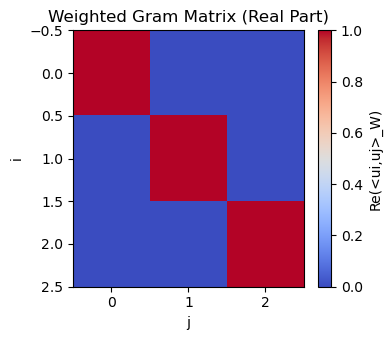

Mean relative weighted reconstruction residual (3 PCs): 0.006722082535101973


In [7]:
# Numerical fidelity checks for weighted EMPCA definition
G = weighted_gram(pcs_f, w_psd)
print('Weighted Gram matrix (first 3 PCs):')
print(G)

plt.figure(figsize=(4,3.5))
plt.imshow(np.real(G), cmap='coolwarm', aspect='auto')
plt.colorbar(label='Re(<ui,uj>_W)')
plt.title('Weighted Gram Matrix (Real Part)')
plt.xlabel('j'); plt.ylabel('i')
plt.tight_layout(); plt.show()

# Reconstruction consistency
C = weighted_project_coeff(Xf, pcs_f, w_psd)
X_rec3 = C @ pcs_f
resid = Xf - X_rec3
rel_rec = np.mean([weighted_norm(r, w_psd)/max(weighted_norm(x, w_psd),1e-30) for r,x in zip(resid, Xf)])
print('Mean relative weighted reconstruction residual (3 PCs):', float(rel_rec))


### Interpretation

If the weighted Gram matrix is close to identity and reconstruction behaves as expected, the whitening+SVD implementation is faithful to weighted EMPCA.


## Hypothesis H1/H2 block: physical meaning of PC1

We compare PC1 against:
- mean waveform direction in frequency domain
- whitened-mean direction mapped back to physical coordinates
- OF-like direction `T/PSD`


In [8]:
mean_time = np.mean(X_time, axis=0)
mean_f = np.mean(Xf, axis=0)
mean_f_ref = normalize_weighted(mean_f, w_psd)

# whitened mean mapped back
sqrtW = np.sqrt(w_psd)
mean_w = mean_f * sqrtW
mean_w_back = normalize_weighted(mean_w / sqrtW, w_psd)

of_dir = normalize_weighted(template_f / np.maximum(psd, CFG['eps_psd']), w_psd)

# sign align PC1 for visualization / interpretation
pc1_sa = sign_align_to_ref(pc1, mean_f_ref, w_psd)

rows = []
for name, ref in [
    ('mean_f', mean_f_ref),
    ('whitened_mean_back', mean_w_back),
    ('of_like_T_over_PSD', of_dir),
]:
    cw = weighted_cosine(pc1_sa, ref, w_psd)
    ang = principal_angle_deg(pc1_sa, ref, w_psd)
    a, r, rr = aligned_residual(pc1_sa, ref, w_psd)
    rows.append((name, cw, ang, rr, np.abs(a), np.degrees(np.angle(a))))

if pd is not None:
    df_pc1 = pd.DataFrame(rows, columns=['reference','cosine_w','angle_deg','rel_resid','abs_alpha','phase_alpha_deg'])
    display(df_pc1)
else:
    print(rows)


,reference,cosine_w,angle_deg,rel_resid,abs_alpha,phase_alpha_deg
0,mean_f,1.000000,0.000011,1.994781e-07,1.000000,-0.017154
1,whitened_mean_back,1.000000,0.000011,1.994781e-07,1.000000,-0.017154
2,of_like_T_over_PSD,0.382567,67.507212,9.239277e-01,0.382567,-0.019196


### PC1 interpretation logic

- If weighted cosine(`PC1`, mean direction) is ~1 and residual is tiny, conclude PC1 equals empirical mean direction up to sign.
- If overlap with `T/PSD` is significantly smaller, conclude PC1 is **not** the OF template direction.
- Sign flips are physically irrelevant (eigenvector sign ambiguity).


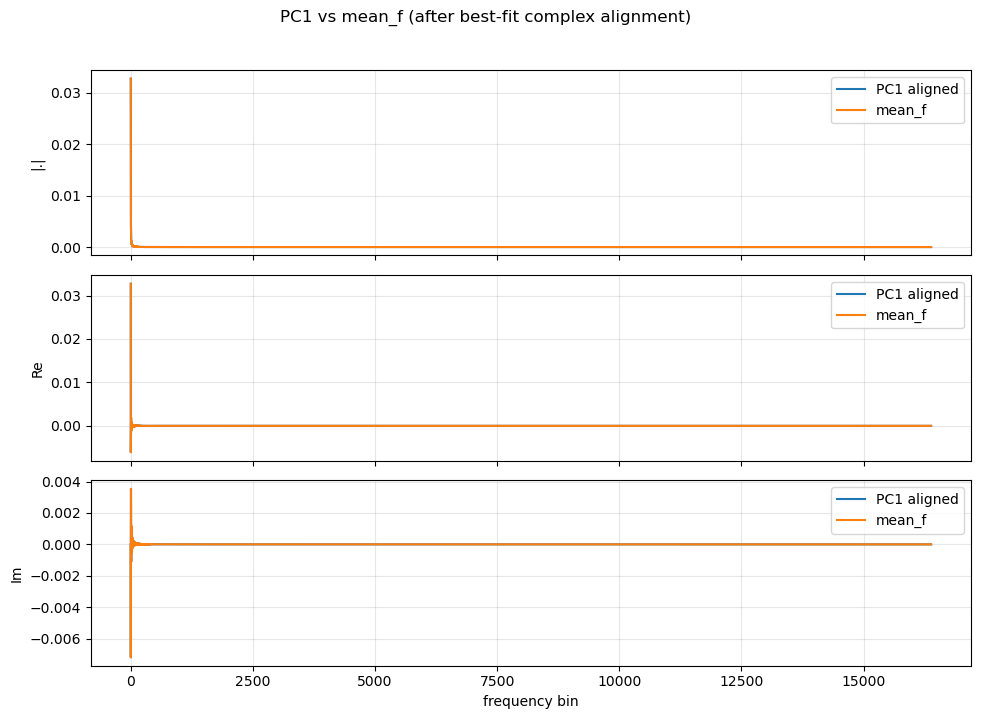

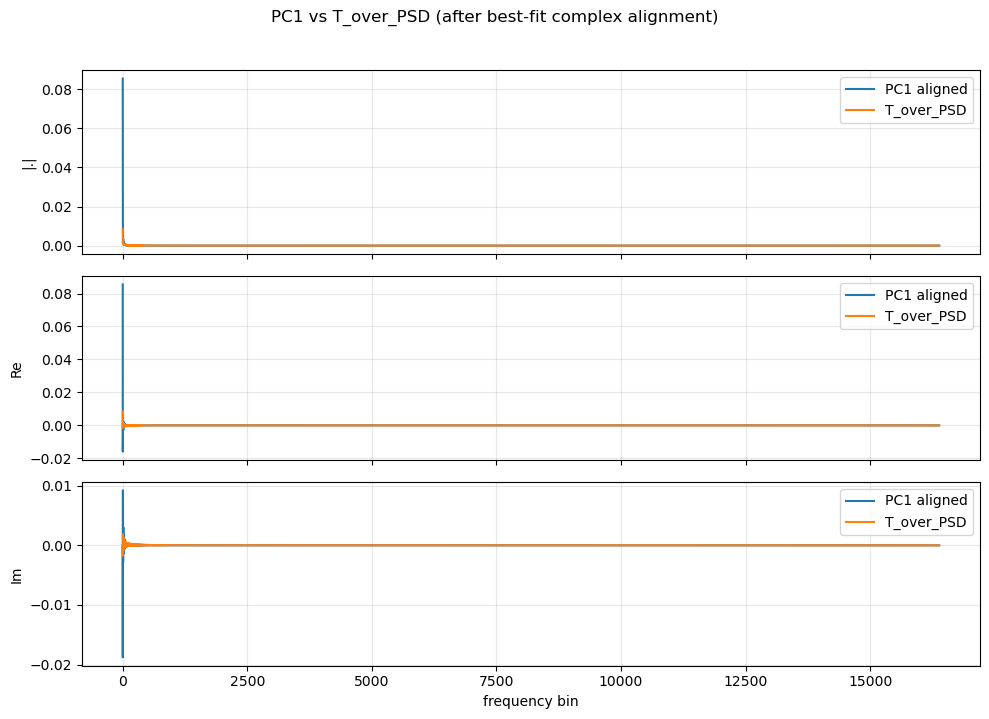

In [9]:
# Visual overlays for PC1 comparisons
x = np.arange(freq_len)
refs_plot = {
    'mean_f': mean_f_ref,
    'T_over_PSD': of_dir,
}
for name, ref in refs_plot.items():
    a = best_fit_alpha(pc1_sa, ref, w_psd)
    p1 = pc1_sa / a

    fig, ax = plt.subplots(3,1, figsize=(10,7), sharex=True)
    ax[0].plot(x, np.abs(p1), label='PC1 aligned')
    ax[0].plot(x, np.abs(ref), label=name)
    ax[0].set_ylabel('|.|'); ax[0].legend(); ax[0].grid(alpha=0.3)

    ax[1].plot(x, np.real(p1), label='PC1 aligned')
    ax[1].plot(x, np.real(ref), label=name)
    ax[1].set_ylabel('Re'); ax[1].legend(); ax[1].grid(alpha=0.3)

    ax[2].plot(x, np.imag(p1), label='PC1 aligned')
    ax[2].plot(x, np.imag(ref), label=name)
    ax[2].set_ylabel('Im'); ax[2].set_xlabel('frequency bin')
    ax[2].legend(); ax[2].grid(alpha=0.3)
    fig.suptitle(f'PC1 vs {name} (after best-fit complex alignment)', y=1.02)
    plt.tight_layout(); plt.show()


## Bootstrap stability test for PC1 (H1 robustness)

We retrain on repeated random subsets and compare subset-PC1 to:
- full-data PC1
- full-data mean direction

High overlap across subsets indicates PC1 is a robust physical direction, not a numerical artifact.


Bootstrap cosine(subset PC1, full PC1): mean/std/min/max = 0.9999999960801794 5.623642339814498e-11 0.9999999958884646 0.9999999962057314
Bootstrap cosine(subset PC1, full mean): mean/std/min/max = 0.9999999960802629 5.615406202263155e-11 0.9999999958880987 0.9999999962057596


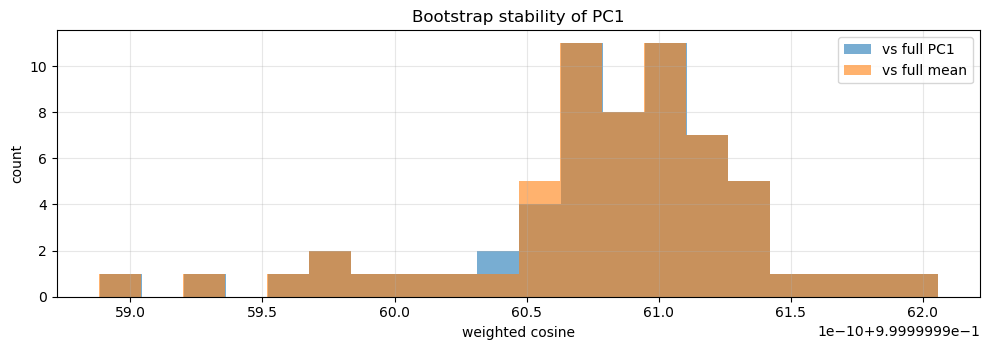

In [10]:
rng = np.random.default_rng(CFG['rng_seed'])

if not CFG['run_bootstrap']:
    print('Bootstrap skipped (CFG["run_bootstrap"] = False).')
else:
    n_rep = CFG['bootstrap_repeats']
    frac = CFG['bootstrap_frac']
    n_sub = int(max(64, frac * Xf.shape[0]))

    cos_pc1 = []
    cos_mean = []

    full_pc1 = pc1_sa.copy()
    full_mean = mean_f_ref.copy()

    for _ in range(n_rep):
        idx = rng.choice(Xf.shape[0], size=n_sub, replace=False)
        res_b = train_clean_empca_weighted(Xf[idx], w_psd, n_components=1, center=False)
        b1 = res_b['pcs_f'][0]
        b1 = sign_align_to_ref(b1, full_pc1, w_psd)
        cos_pc1.append(weighted_cosine(b1, full_pc1, w_psd))
        cos_mean.append(weighted_cosine(b1, full_mean, w_psd))

    cos_pc1 = np.asarray(cos_pc1)
    cos_mean = np.asarray(cos_mean)

    print('Bootstrap cosine(subset PC1, full PC1): mean/std/min/max =',
          float(np.mean(cos_pc1)), float(np.std(cos_pc1)), float(np.min(cos_pc1)), float(np.max(cos_pc1)))
    print('Bootstrap cosine(subset PC1, full mean): mean/std/min/max =',
          float(np.mean(cos_mean)), float(np.std(cos_mean)), float(np.min(cos_mean)), float(np.max(cos_mean)))

    plt.figure(figsize=(10,3.6))
    plt.hist(cos_pc1, bins=20, alpha=0.6, label='vs full PC1')
    plt.hist(cos_mean, bins=20, alpha=0.6, label='vs full mean')
    plt.xlabel('weighted cosine'); plt.ylabel('count')
    plt.title('Bootstrap stability of PC1')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Centering ablation

Compare uncentered vs centered training:
- uncentered PC1 should track mean direction
- centered PC1 should track dominant variation around mean


cos(uncentered PC1, mean_f): 0.9999999999999805
cos(centered   PC1, mean_f): 0.9884855851492987


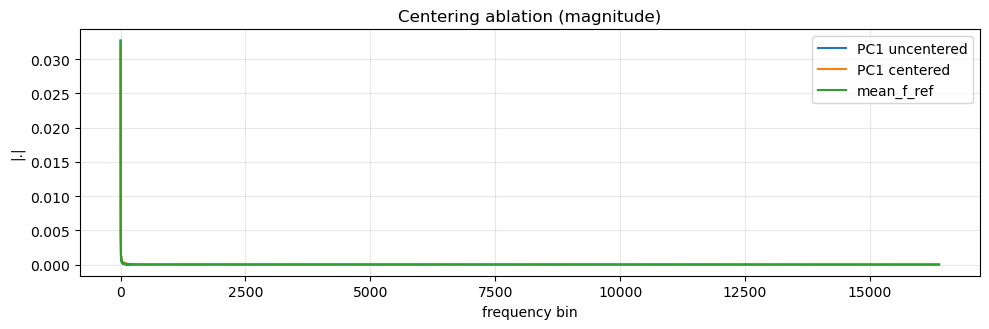

In [11]:
if not CFG['run_centering_ablation']:
    print('Centering ablation skipped.')
else:
    res_ctr = train_clean_empca_weighted(Xf, w_psd, n_components=3, center=True)
    pc1_ctr = sign_align_to_ref(res_ctr['pcs_f'][0], mean_f_ref, w_psd)

    c_unc = weighted_cosine(pc1_sa, mean_f_ref, w_psd)
    c_ctr = weighted_cosine(pc1_ctr, mean_f_ref, w_psd)

    print('cos(uncentered PC1, mean_f):', float(c_unc))
    print('cos(centered   PC1, mean_f):', float(c_ctr))

    xt = np.arange(freq_len)
    plt.figure(figsize=(10,3.4))
    plt.plot(xt, np.abs(pc1_sa), label='PC1 uncentered')
    plt.plot(xt, np.abs(pc1_ctr), label='PC1 centered')
    plt.plot(xt, np.abs(mean_f_ref), label='mean_f_ref')
    plt.title('Centering ablation (magnitude)')
    plt.xlabel('frequency bin'); plt.ylabel('|.|')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## Hypothesis H3 block: physical interpretation of PC2 and PC3

We test whether PC2/PC3 represent timing jitter, width variation, or other shape distortions.


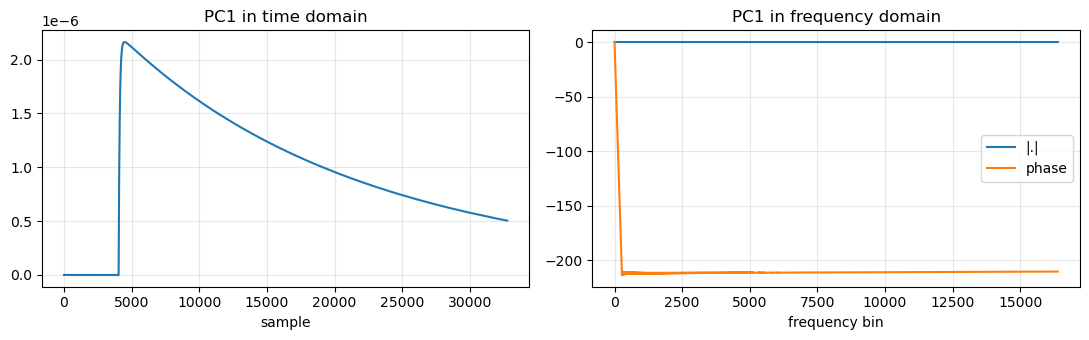

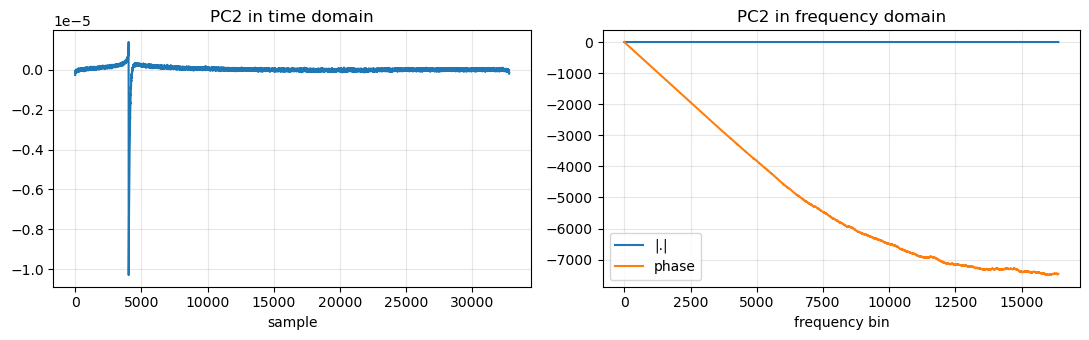

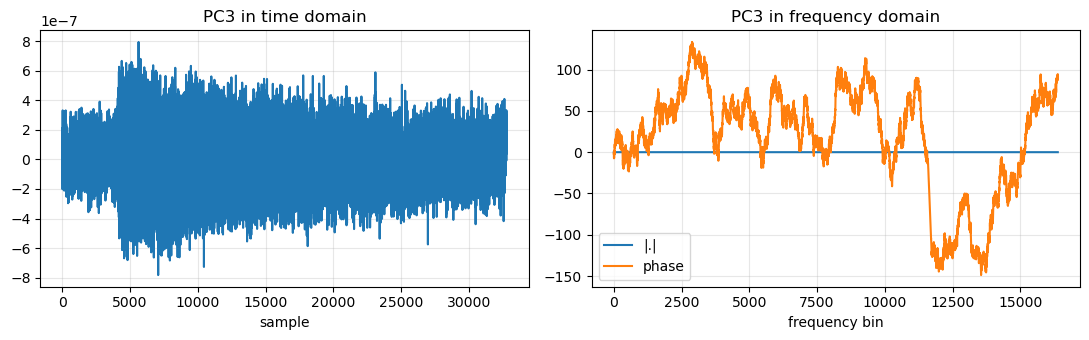

In [12]:
# Basic PC2/PC3 visualizations in frequency and time domains
pcs = [pc1_sa, pc2, pc3]
labels = ['PC1','PC2','PC3']

for u, lab in zip(pcs, labels):
    u_t = to_time(u, n_time=X_time.shape[1])[0]

    fig, ax = plt.subplots(1,2, figsize=(11,3.5))
    ax[0].plot(u_t)
    ax[0].set_title(f'{lab} in time domain')
    ax[0].set_xlabel('sample'); ax[0].grid(alpha=0.3)

    ax[1].plot(np.abs(u), label='|.|')
    ax[1].plot(np.unwrap(np.angle(u)), label='phase')
    ax[1].set_title(f'{lab} in frequency domain')
    ax[1].set_xlabel('frequency bin'); ax[1].legend(); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


### Test timing-shift hypothesis using derivative direction

For small shifts: `s(t-dt) ≈ s(t) - dt * s'(t)`.
If a component is timing-like, it should align with derivative of mean pulse.


In [13]:
mean_dt = np.gradient(mean_time)
deriv_f = to_freq(mean_dt)[0]
deriv_f = normalize_weighted(deriv_f, w_psd)

for lab, u in [('PC2', pc2), ('PC3', pc3)]:
    u_sa = sign_align_to_ref(u, deriv_f, w_psd)
    cw = weighted_cosine(u_sa, deriv_f, w_psd)
    ang = principal_angle_deg(u_sa, deriv_f, w_psd)
    rr = aligned_residual(u_sa, deriv_f, w_psd)[2]
    print(f'{lab} vs d(mean)/dt: cosine={cw:.6f}, angle={ang:.4f} deg, rel_res={rr:.4e}')


PC2 vs d(mean)/dt: cosine=0.968591, angle=14.3983 deg, rel_res=2.4866e-01
PC3 vs d(mean)/dt: cosine=0.003598, angle=89.7938 deg, rel_res=9.9999e-01


### Width and shape deformation tests

Create controlled deformations of the mean pulse (stretch/compress/rise/fall modulation), convert to frequency-domain deformation vectors, and compare with PC2/PC3.


In [14]:
def deform_stretch(x, factor):
    n = len(x)
    t = np.arange(n)
    t0 = t - (n-1)/2
    ts = t0 / factor + (n-1)/2
    return np.interp(t, ts, x, left=x[0], right=x[-1])


def deform_rise_fall(x, rise_scale=1.0, fall_scale=1.0):
    y = x.copy()
    pk = int(np.argmax(np.abs(y)))
    y[:pk] *= rise_scale
    y[pk:] *= fall_scale
    return y


def deformation_vector(x_ref, x_def, w):
    d = x_def - x_ref
    df = to_freq(d)[0]
    return normalize_weighted(df, w)

candidates = {}

x0 = mean_time
candidates['stretch_+2%'] = deformation_vector(x0, deform_stretch(x0, 1.02), w_psd)
candidates['compress_-2%'] = deformation_vector(x0, deform_stretch(x0, 0.98), w_psd)
candidates['rise+2%_fall-2%'] = deformation_vector(x0, deform_rise_fall(x0, 1.02, 0.98), w_psd)
candidates['rise-2%_fall+2%'] = deformation_vector(x0, deform_rise_fall(x0, 0.98, 1.02), w_psd)

rows_h3 = []
for cname, v in candidates.items():
    for lab, u in [('PC2', pc2), ('PC3', pc3)]:
        us = sign_align_to_ref(u, v, w_psd)
        rows_h3.append((lab, cname,
                        weighted_cosine(us, v, w_psd),
                        principal_angle_deg(us, v, w_psd),
                        aligned_residual(us, v, w_psd)[2]))

if pd is not None:
    df_h3 = pd.DataFrame(rows_h3, columns=['pc','deformation','cosine_w','angle_deg','rel_resid'])
    display(df_h3.sort_values(['pc','cosine_w'], ascending=[True,False]))
else:
    print(rows_h3)


,pc,deformation,cosine_w,angle_deg,rel_resid
2,PC2,compress_-2%,0.495911,60.270159,0.868373
0,PC2,stretch_+2%,0.485440,60.958682,0.874270
6,PC2,rise-2%_fall+2%,0.238929,76.176648,0.971037
4,PC2,rise+2%_fall-2%,0.238929,76.176648,0.971037
3,PC3,compress_-2%,0.007550,89.567403,0.999971
7,PC3,rise-2%_fall+2%,0.006253,89.641699,0.999980
5,PC3,rise+2%_fall-2%,0.006253,89.641699,0.999980
1,PC3,stretch_+2%,0.005393,89.691010,0.999985


### Projection coefficient analysis on real events

We compute `a1, a2, a3` and correlate `a2/a3` with timing and width proxies.


corr(Re(a2), timing_proxy) = 0.01585880022917493
corr(Re(a3), width_proxy)  = 0.003390557955939079
corr(Re(a2), Re(a3))       = -0.00028537560648526434


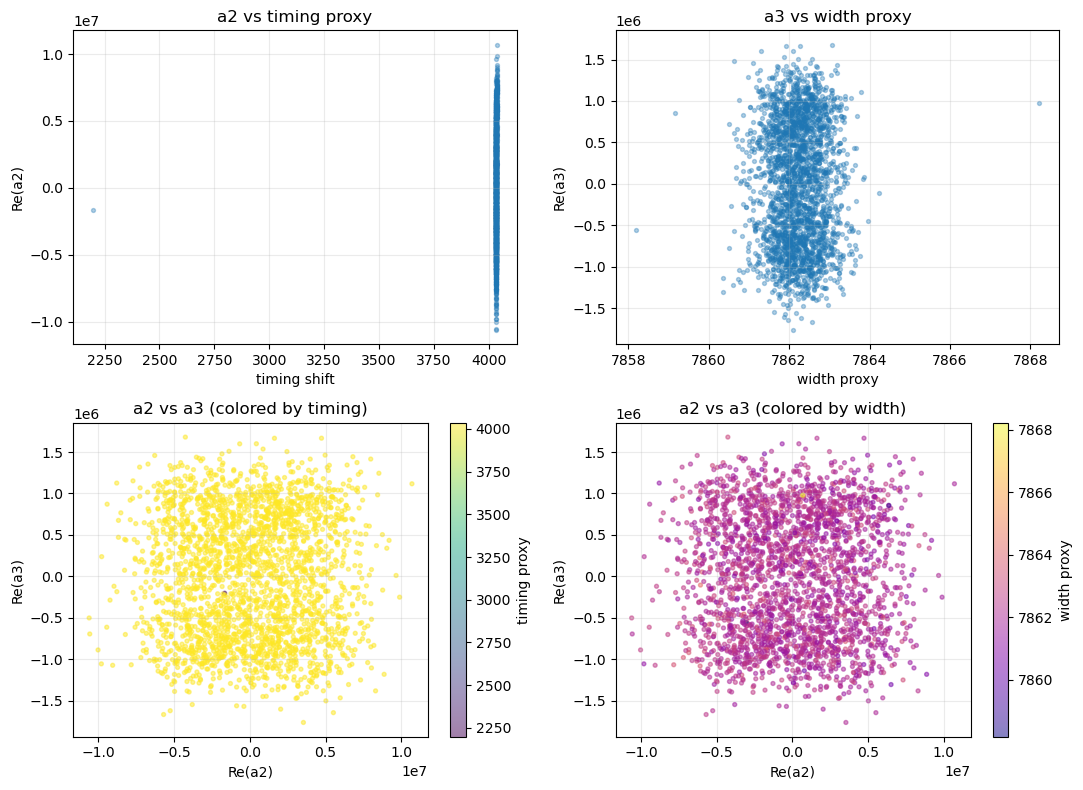

In [15]:
A = coeff[:, :3]
a1, a2, a3 = A[:,0], A[:,1], A[:,2]

# Proxies
amp_proxy = np.real(np.array([weighted_inner(mean_f_ref, x, w_psd) for x in Xf]))

# timing proxy from cross-correlation with mean_time
ref = mean_time - np.mean(mean_time)
ref_n = np.linalg.norm(ref) + 1e-30

def timing_proxy(trace):
    z = trace - np.mean(trace)
    c = np.correlate(z, ref, mode='full')
    return np.argmax(c) - (len(ref)-1)

t_shift = np.array([timing_proxy(x) for x in X_time], dtype=float)

# width proxy: second central moment around abs peak
idx = np.arange(X_time.shape[1])

def width_proxy(trace):
    w = np.abs(trace)
    s = np.sum(w) + 1e-30
    mu = np.sum(idx*w)/s
    var = np.sum(((idx-mu)**2)*w)/s
    return np.sqrt(max(var, 0.0))

w_proxy = np.array([width_proxy(x) for x in X_time], dtype=float)

if rqs is not None and rqs.dtype.names and 'time_shift' in rqs.dtype.names:
    t_shift_rqs = np.asarray(rqs['time_shift'], dtype=float)
else:
    t_shift_rqs = t_shift

if rqs is not None and rqs.dtype.names and 'rise_time' in rqs.dtype.names:
    rise_proxy = np.asarray(rqs['rise_time'], dtype=float)
else:
    rise_proxy = w_proxy


def safe_corr(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

print('corr(Re(a2), timing_proxy) =', safe_corr(np.real(a2), t_shift_rqs))
print('corr(Re(a3), width_proxy)  =', safe_corr(np.real(a3), w_proxy))
print('corr(Re(a2), Re(a3))       =', safe_corr(np.real(a2), np.real(a3)))

fig, ax = plt.subplots(2,2, figsize=(11,8))
ax[0,0].scatter(t_shift_rqs, np.real(a2), s=8, alpha=0.35)
ax[0,0].set_title('a2 vs timing proxy')
ax[0,0].set_xlabel('timing shift'); ax[0,0].set_ylabel('Re(a2)')

ax[0,1].scatter(w_proxy, np.real(a3), s=8, alpha=0.35)
ax[0,1].set_title('a3 vs width proxy')
ax[0,1].set_xlabel('width proxy'); ax[0,1].set_ylabel('Re(a3)')

sc = ax[1,0].scatter(np.real(a2), np.real(a3), c=t_shift_rqs, s=8, alpha=0.5, cmap='viridis')
ax[1,0].set_title('a2 vs a3 (colored by timing)')
ax[1,0].set_xlabel('Re(a2)'); ax[1,0].set_ylabel('Re(a3)')
plt.colorbar(sc, ax=ax[1,0], label='timing proxy')

sc2 = ax[1,1].scatter(np.real(a2), np.real(a3), c=w_proxy, s=8, alpha=0.5, cmap='plasma')
ax[1,1].set_title('a2 vs a3 (colored by width)')
ax[1,1].set_xlabel('Re(a2)'); ax[1,1].set_ylabel('Re(a3)')
plt.colorbar(sc2, ax=ax[1,1], label='width proxy')

for a in ax.ravel():
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()


### Reconstruction experiments with 1/2/3 PCs

We quantify how much PC2/PC3 improve reconstruction and inspect event types that benefit most.


Mean relative weighted residual:
  1 PC : 0.006770158188681468
  2 PCs: 0.006725664530773631
  3 PCs: 0.006722082535101973
Top improved event indices: [ 683 1765 2061  230 1803  240]


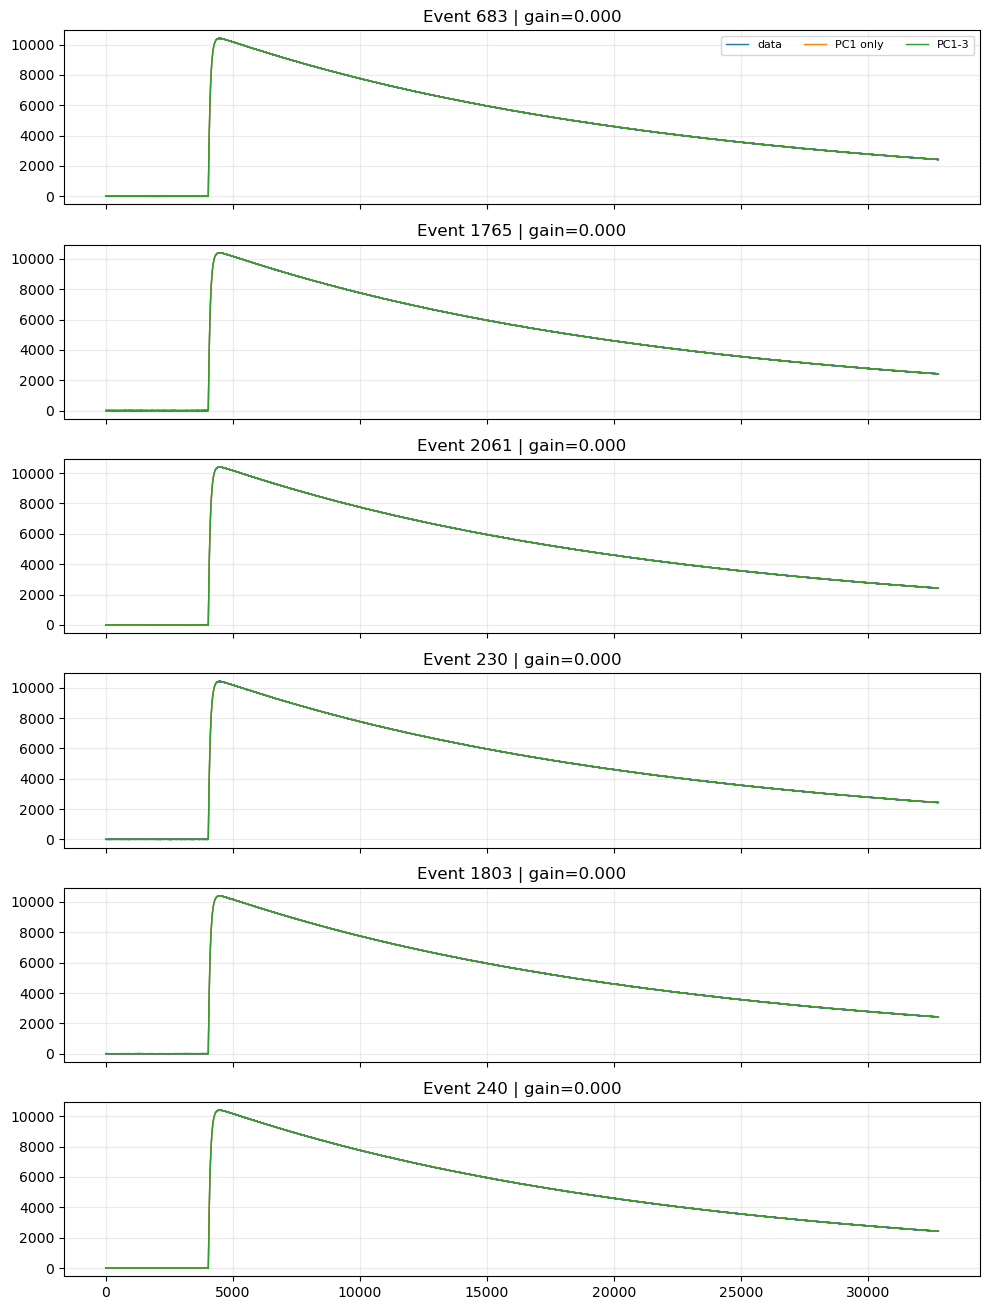

In [16]:
def reconstruct_from_pcs(coeff_mat, pcs):
    return coeff_mat @ pcs

C1 = coeff[:, :1]
C2 = coeff[:, :2]
C3 = coeff[:, :3]

R1 = reconstruct_from_pcs(C1, pcs_f[:1])
R2 = reconstruct_from_pcs(C2, pcs_f[:2])
R3 = reconstruct_from_pcs(C3, pcs_f[:3])


def mean_rel_res(X, R, w):
    rr = []
    for x, r in zip(X, R):
        rr.append(weighted_norm(x-r, w)/max(weighted_norm(x, w), 1e-30))
    return float(np.mean(rr)), np.asarray(rr)

m1, rr1 = mean_rel_res(Xf, R1, w_psd)
m2, rr2 = mean_rel_res(Xf, R2, w_psd)
m3, rr3 = mean_rel_res(Xf, R3, w_psd)

print('Mean relative weighted residual:')
print('  1 PC :', m1)
print('  2 PCs:', m2)
print('  3 PCs:', m3)

# events most improved by adding PC2/PC3
gain = rr1 - rr3
idx_best = np.argsort(gain)[-6:]
print('Top improved event indices:', idx_best)

if CFG['show_time_domain_diagnostics']:
    fig, axes = plt.subplots(len(idx_best), 1, figsize=(10, 2.2*len(idx_best)), sharex=True)
    if len(idx_best) == 1:
        axes = [axes]
    for ax, i in zip(axes, idx_best):
        x_t = X_time[i]
        r1_t = to_time(R1[i], n_time=X_time.shape[1])[0]
        r3_t = to_time(R3[i], n_time=X_time.shape[1])[0]
        ax.plot(x_t, label='data', lw=1)
        ax.plot(r1_t, label='PC1 only', lw=1)
        ax.plot(r3_t, label='PC1-3', lw=1)
        ax.set_title(f'Event {i} | gain={gain[i]:.3f}')
        ax.grid(alpha=0.25)
    axes[0].legend(ncol=3, fontsize=8)
    plt.tight_layout(); plt.show()


## Toy-model validation

We generate synthetic datasets with known modes (amplitude, timing, width) and test whether EMPCA recovers expected directions:
- signal direction `s`
- derivative `s'` (timing-like)
- width-deformation direction


In [17]:
rng = np.random.default_rng(CFG['rng_seed'] + 123)


def shift_waveform(x, dt):
    t = np.arange(len(x))
    return np.interp(t-dt, t, x, left=x[0], right=x[-1])


def width_waveform(x, factor):
    return deform_stretch(x, factor)


def add_noise_freq(xf, psd_vec, rng_local):
    # simple complex Gaussian noise model in frequency domain
    n = len(xf)
    z = (rng_local.normal(size=n) + 1j*rng_local.normal(size=n)) * np.sqrt(psd_vec/2.0)
    z[0] = np.real(z[0])
    if n > 1:
        z[-1] = np.real(z[-1])
    return xf + z


def build_toy_dataset(mode, n_events=1200):
    Xtoy_f = []
    for _ in range(n_events):
        amp = 1.0 + 0.08*rng.normal()
        dt = 0.0
        wf = 1.0

        if mode in ['timing', 'amp_timing', 'full']:
            dt = 2.0*rng.normal()
        if mode in ['width', 'full']:
            wf = 1.0 + 0.03*rng.normal()

        s = amp * width_waveform(shift_waveform(mean_time, dt), wf)
        sf = to_freq(s)[0][:freq_len]
        sf_n = add_noise_freq(sf, psd[:freq_len], rng)
        Xtoy_f.append(sf_n)
    return np.asarray(Xtoy_f)

if not CFG['run_toy_validation']:
    print('Toy validation skipped.')
else:
    modes = ['amp_only', 'timing', 'width', 'amp_timing', 'full']

    # expected analytic directions in frequency domain
    dir_s = normalize_weighted(to_freq(mean_time)[0][:freq_len], w_psd)
    dir_d = normalize_weighted(to_freq(np.gradient(mean_time))[0][:freq_len], w_psd)
    dir_w = normalize_weighted(deformation_vector(mean_time, width_waveform(mean_time, 1.02), w_psd), w_psd)

    toy_rows = []
    for m in modes:
        Xt = build_toy_dataset(m, n_events=CFG['toy_n_events'])
        rt = train_clean_empca_weighted(Xt, w_psd, n_components=3, center=False)
        p1t, p2t, p3t = rt['pcs_f']

        # sign-align per reference for reporting only
        p1t = sign_align_to_ref(p1t, dir_s, w_psd)
        p2t = sign_align_to_ref(p2t, dir_d, w_psd)

        toy_rows.append((m,
                         weighted_cosine(p1t, dir_s, w_psd),
                         weighted_cosine(p2t, dir_d, w_psd),
                         weighted_cosine(p3t, dir_w, w_psd)))

    if pd is not None:
        df_toy = pd.DataFrame(toy_rows, columns=['mode','cos(PC1,signal)','cos(PC2,derivative)','cos(PC3,width_dir)'])
        display(df_toy)
    else:
        print(toy_rows)


,mode,"cos(PC1,signal)","cos(PC2,derivative)","cos(PC3,width_dir)"
0,amp_only,1.000000,0.002710,0.002075
1,timing,1.000000,0.978905,0.248210
2,width,0.988626,0.328536,0.516338
3,amp_timing,1.000000,0.979165,0.246340
4,full,0.988487,0.326940,0.523347


## Physics-level performance checks

This section compares EMPCA vs OF-like amplitude proxies on noise/signal subsets.


Noise resolution proxy (std, FWHM):
 EMPCA: 992688.463285209 2337602.6918140375
 OF   : 969232.2927472126 2282367.631251521
 relative std diff EMPCA/OF -1 = 0.024200772831775685
d-prime proxy EMPCA: 2.7391099073159353
d-prime proxy OF   : 2.8054185145554555
Linearity slope/intercept EMPCA: [  167239.4211 97881909.963 ]
Linearity slope/intercept OF   : [  167903.2503 90964311.0617]


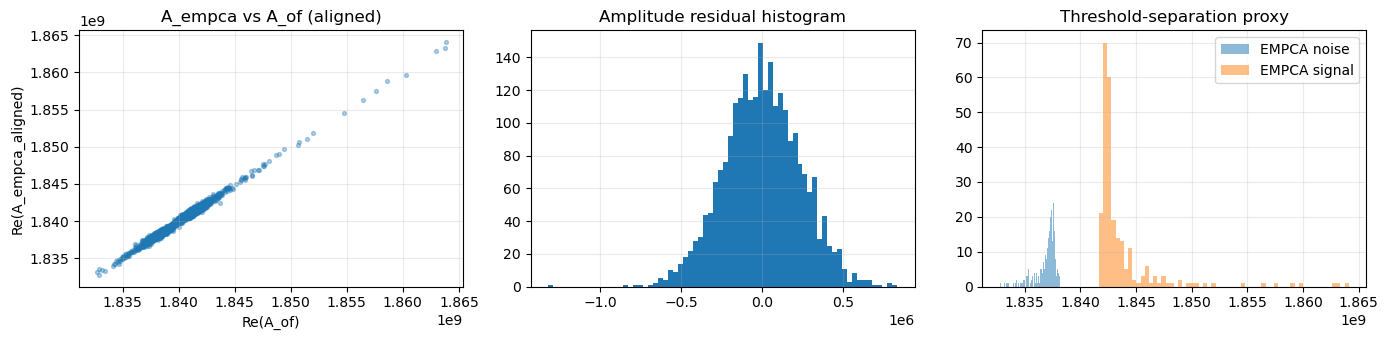

In [18]:
# Amplitude proxies
v_emp = pc1_sa
v_of = of_dir

A_emp = np.array([weighted_inner(v_emp, x, w_psd) / weighted_inner(v_emp, v_emp, w_psd) for x in Xf])
A_of = np.array([weighted_inner(v_of, x, w_psd) / weighted_inner(v_of, v_of, w_psd) for x in Xf])

# complex alignment for comparison
alpha_amp = np.vdot(A_of, A_emp) / max(np.vdot(A_of, A_of), 1e-30)
A_emp_al = A_emp / alpha_amp

# proxy split by amplitude quantiles
xamp = np.real(A_of)
q1, q9 = np.quantile(xamp, [0.1, 0.9])
noise_idx = xamp <= q1
signal_idx = xamp >= q9


def fwhm_from_std(s):
    return 2.35482004503 * s

std_emp = np.std(np.real(A_emp_al[noise_idx]))
std_of = np.std(np.real(A_of[noise_idx]))

print('Noise resolution proxy (std, FWHM):')
print(' EMPCA:', float(std_emp), float(fwhm_from_std(std_emp)))
print(' OF   :', float(std_of), float(fwhm_from_std(std_of)))
print(' relative std diff EMPCA/OF -1 =', float(std_emp/std_of - 1.0))

# detection/separation proxy
mu_ne, mu_se = np.mean(np.real(A_emp_al[noise_idx])), np.mean(np.real(A_emp_al[signal_idx]))
sd_ne, sd_se = np.std(np.real(A_emp_al[noise_idx])), np.std(np.real(A_emp_al[signal_idx]))

mu_no, mu_so = np.mean(np.real(A_of[noise_idx])), np.mean(np.real(A_of[signal_idx]))
sd_no, sd_so = np.std(np.real(A_of[noise_idx])), np.std(np.real(A_of[signal_idx]))

dp_emp = (mu_se - mu_ne) / max(np.sqrt(0.5*(sd_ne**2 + sd_se**2)), 1e-30)
dp_of = (mu_so - mu_no) / max(np.sqrt(0.5*(sd_no**2 + sd_so**2)), 1e-30)
print('d-prime proxy EMPCA:', float(dp_emp))
print('d-prime proxy OF   :', float(dp_of))

# linearity proxy vs rqs['A'] when available
if rqs is not None and rqs.dtype.names and ('A' in rqs.dtype.names):
    E = np.asarray(rqs['A'], dtype=float)
    m = np.isfinite(E)
    c_emp = np.polyfit(E[m], np.real(A_emp_al)[m], 1)
    c_of = np.polyfit(E[m], np.real(A_of)[m], 1)
    print('Linearity slope/intercept EMPCA:', c_emp)
    print('Linearity slope/intercept OF   :', c_of)

fig, ax = plt.subplots(1,3, figsize=(14,3.5))
ax[0].scatter(np.real(A_of), np.real(A_emp_al), s=8, alpha=0.35)
ax[0].set_title('A_empca vs A_of (aligned)')
ax[0].set_xlabel('Re(A_of)'); ax[0].set_ylabel('Re(A_empca_aligned)')

res_amp = np.real(A_emp_al) - np.real(A_of)
ax[1].hist(res_amp, bins=70)
ax[1].set_title('Amplitude residual histogram')

ax[2].hist(np.real(A_emp_al[noise_idx]), bins=60, alpha=0.5, label='EMPCA noise')
ax[2].hist(np.real(A_emp_al[signal_idx]), bins=60, alpha=0.5, label='EMPCA signal')
ax[2].set_title('Threshold-separation proxy')
ax[2].legend()

for a in ax:
    a.grid(alpha=0.25)
plt.tight_layout(); plt.show()


## Verification criteria and verdict

Practical criteria:
- directional: cosine near 1, principal angle near 0 deg, relative residual much less than 1
- implementation: weighted Gram matrix close to identity
- amplitude/performance: high correlation and similar noise-resolution/separation

Conclusions should be conservative and metric-based.


In [19]:
# Collect key outcomes for concise scientific verdict

pc1_vs_mean = weighted_cosine(pc1_sa, mean_f_ref, w_psd)
pc1_vs_of = weighted_cosine(pc1_sa, of_dir, w_psd)
rr_pc1_mean = aligned_residual(pc1_sa, mean_f_ref, w_psd)[2]
rr_pc1_of = aligned_residual(pc1_sa, of_dir, w_psd)[2]

pc2_vs_deriv = weighted_cosine(sign_align_to_ref(pc2, deriv_f, w_psd), deriv_f, w_psd)
pc3_vs_deriv = weighted_cosine(sign_align_to_ref(pc3, deriv_f, w_psd), deriv_f, w_psd)

print('=== Final Summary ===')
print(f'PC1 vs mean_f: cosine={pc1_vs_mean:.6f}, rel_res={rr_pc1_mean:.3e}')
print(f'PC1 vs T/PSD : cosine={pc1_vs_of:.6f}, rel_res={rr_pc1_of:.3e}')
print(f'PC2 vs d(mean)/dt cosine={pc2_vs_deriv:.6f}')
print(f'PC3 vs d(mean)/dt cosine={pc3_vs_deriv:.6f}')

if pc1_vs_mean > 0.999 and rr_pc1_mean < 1e-2:
    print('PC1 conclusion: PC1 is numerically the empirical mean direction (up to sign/phase).')
elif pc1_vs_mean > 0.95:
    print('PC1 conclusion: PC1 is strongly mean-like, but not exact.')
else:
    print('PC1 conclusion: PC1 is not close to mean direction under current setup.')

if pc1_vs_of + 0.02 < pc1_vs_mean:
    print('H2 supported: PC1 is not the OF direction; OF-like direction is distinct from empirical PC1.')
else:
    print('H2 inconclusive: OF similarity is comparable; inspect assumptions carefully.')

print('PC2/PC3 conclusion must be based on derivative/deformation overlap + coefficient correlations above.')


=== Final Summary ===
PC1 vs mean_f: cosine=1.000000, rel_res=1.995e-07
PC1 vs T/PSD : cosine=0.382567, rel_res=9.239e-01
PC2 vs d(mean)/dt cosine=0.968591
PC3 vs d(mean)/dt cosine=0.003598
PC1 conclusion: PC1 is numerically the empirical mean direction (up to sign/phase).
H2 supported: PC1 is not the OF direction; OF-like direction is distinct from empirical PC1.
PC2/PC3 conclusion must be based on derivative/deformation overlap + coefficient correlations above.


### Final interpretation notes

- **PC1**: dominant empirical waveform direction learned from data under weighted metric.
- **Mean waveform direction**: empirical average direction in the training domain.
- **OF template direction**: matched-filter-like direction (`T/PSD`) for optimal amplitude estimation.

These are related but not automatically identical. This notebook verifies the distinctions numerically.
